In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

from dpks import QuantMatrix

custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(context="paper", style="ticks", rc=custom_params, font="Arial")

In [2]:

def preprocess_design_matrix(design_matrix):

    design_matrix = design_matrix[
        ((design_matrix['Sepsis Prob'] >= 0.8) | 
        (design_matrix['Sepsis Prob'] <= 0.50))
    ].copy()

    design_matrix['group'] = np.where(
        design_matrix['Sepsis Prob'] > 0.65, 2, 1
    )

    design_matrix['sample'] = design_matrix['injection']

    return design_matrix

In [3]:
def preprocess_data(raw_data, design_matrix):

    quant_matrix = QuantMatrix(
        quantification_file=raw_data[['Protein'] + [sample for sample in design_matrix['sample'].values]].copy(),
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_clinical_data/2023-04-24-UP000005640.fas"
    )

    quant_data = quant_matrix.to_df()
    
    quant_data = quant_data[~((quant_data["ProteinLabel"].str.startswith("HV")) | (quant_data["ProteinLabel"].str.startswith("LV")) | quant_data["ProteinLabel"].str.startswith("KV"))]
    quant_data = quant_data[~quant_data["ProteinLabel"].str.startswith("IG")]
    quant_data = quant_data[~((quant_data["ProteinLabel"] == "HBA_HUMAN") | (quant_data["ProteinLabel"] == "HBB_HUMAN") | (quant_data["ProteinLabel"] == "HBD_HUMAN") | (quant_data["ProteinLabel"] == "HEMO_HUMAN"))]


    quant_matrix = QuantMatrix(
        quantification_file=quant_data,
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_clinical_data/2023-04-24-UP000005640.fas"
    )

    return quant_matrix.annotate()     


In [4]:
def preprocess_test_data(raw_data, design_matrix):

    quant_matrix = QuantMatrix(
        quantification_file=raw_data[['Protein'] + [sample for sample in design_matrix['sample'].values]].copy(),
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_clinical_data/2023-04-24-UP000005640.fas"
    )

    quant_data = quant_matrix.to_df()
    
    quant_data = quant_data[~((quant_data["ProteinLabel"].str.startswith("HV")) | (quant_data["ProteinLabel"].str.startswith("LV")) | quant_data["ProteinLabel"].str.startswith("KV"))]
    quant_data = quant_data[~quant_data["ProteinLabel"].str.startswith("IG")]
    quant_data = quant_data[~((quant_data["ProteinLabel"] == "HBA_HUMAN") | (quant_data["ProteinLabel"] == "HBB_HUMAN") | (quant_data["ProteinLabel"] == "HBD_HUMAN") | (quant_data["ProteinLabel"] == "HEMO_HUMAN"))]

    quant_matrix = QuantMatrix(
        quantification_file=quant_data,
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_clinical_data/2023-04-24-UP000005640.fas"
    )

    return quant_matrix.annotate()   

# Model Training

In [5]:
ms_data = pd.read_csv(
    "../1_proteomics_data/protein_test_filtered.tsv"
    , sep="\t"
)

In [6]:
design_matrix_otrain = pd.read_csv(
    "../3_clinical_digital_family/design_matrix_test_sepsis_risk.tsv",
    sep='\t'
)

In [7]:
design_matrix_otrain

,injection,sao2_ambulance,resp_frequency_ambulance,heart_rate_ambulance,syst_bp_ambulance,map_ambulance,mental_status_ambulance,temperature_ambulance,crea_emergency_department,bili_emergency_department,...,target_bootstrap_990,target_bootstrap_991,target_bootstrap_992,target_bootstrap_993,target_bootstrap_994,target_bootstrap_995,target_bootstrap_996,target_bootstrap_997,target_bootstrap_998,target_bootstrap_999
0,SA_BOX_9-159_S1-D9_1_6172,-0.440508,-0.373111,-1.132467,0.755411,0.270374,1.0,0.304580,-0.242471,-8.225653e-01,...,0.5,0.6,0.5,0.5,0.5,0.5,0.5,0.5,0.5,0.5
1,SA_BOX_7-267_S4-H8_1_5971,0.582753,-1.107689,2.044809,-1.263782,-1.356894,1.0,-1.060908,0.221389,-3.704361e-01,...,0.6,0.9,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6
2,SA_BOX_15-464_S4-G9_1_6763,-0.781594,0.606327,0.564982,1.260209,0.000000,1.0,-0.085559,-0.566094,-2.677143e-16,...,0.8,0.8,0.8,0.8,0.9,0.7,0.8,0.7,0.9,0.8
3,SA_BOX_2-1700_S2-D11_1_6971,0.355362,-1.842267,-0.523127,-0.903212,0.000000,1.0,0.011975,0.987296,1.362726e+00,...,0.7,0.9,0.7,0.7,0.7,0.7,0.7,0.8,0.7,0.8
4,SA_BOX_7-1728_S4-F9_1_5977,-0.781594,-0.128251,-0.218456,-0.182072,0.000000,1.0,0.011975,0.447924,-2.677143e-16,...,0.3,0.3,0.4,0.3,0.2,0.2,0.3,0.2,0.3,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
675,SA_BOX_6-659_S2-F10_1_5887,-0.326812,-0.373111,-0.914846,-1.444067,-1.549597,1.0,0.011975,0.221389,-2.677143e-16,...,1.0,0.9,0.9,0.9,0.9,1.0,0.9,0.9,0.9,0.9
676,SA_BOX_7-2061_S4-H5_1_5946,0.810144,-0.862829,0.956701,-0.650813,0.291785,1.0,0.011975,-0.717118,6.338260e-03,...,0.5,0.5,0.5,0.6,0.4,0.5,0.5,0.5,0.5,0.5
677,SA_BOX_2-764_S2-G2_1_6901,0.127971,0.116608,-2.264100,-0.903212,-1.142780,1.0,-0.183094,0.178239,8.169313e-02,...,0.8,0.9,0.9,0.9,0.9,0.9,0.9,1.0,0.9,0.9
678,SA_BOX_6-774_S2-D10_1_5885,1.151231,-0.373111,0.347360,-0.903212,0.000000,1.0,-0.768303,-0.328770,-2.950812e-01,...,0.7,0.8,0.8,0.7,0.7,0.7,0.7,0.7,0.7,0.9


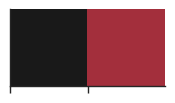

In [8]:
custom_palette = ["k", "#A32F3C"]  # Define hex colors
palette = sns.color_palette(custom_palette, as_cmap=True)
sns.palplot(custom_palette)

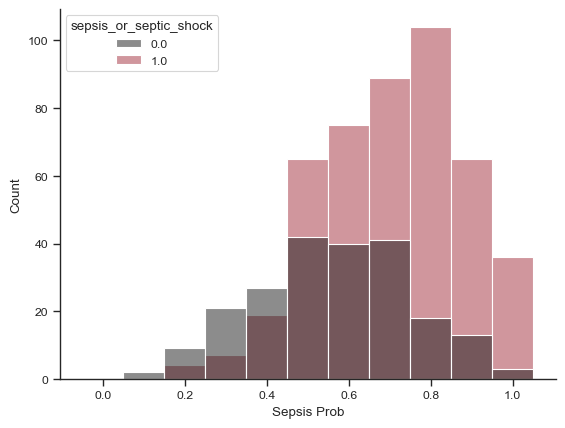

In [9]:
g = sns.histplot(
    design_matrix_otrain,
    x="Sepsis Prob",
    hue="sepsis_or_septic_shock",
    palette=palette,
    binwidth=0.1,
    binrange=(-0.05, 1.05),
    #multiple="stack",
    bins=10,
    # kde=True
)

sns.despine()

g.figure.savefig("sepsis_diagnosis_probability.pdf", dpi=300, bbox_inches="tight")

In [10]:
design_matrix_train = preprocess_design_matrix(design_matrix_otrain.copy())

In [11]:
design_matrix_train['group'].value_counts()

group
2    188
1    142
Name: count, dtype: int64

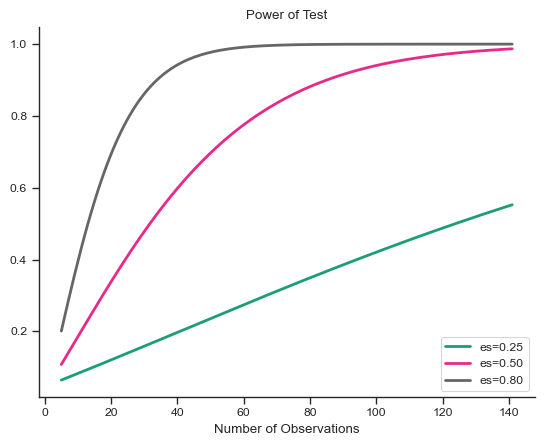

<Figure size 640x480 with 0 Axes>

In [12]:
from statsmodels.stats.power import TTestIndPower
import matplotlib.pyplot as plt

# parameters for power analysis
effect_sizes = np.array([0.25, 0.5, 0.8])
sample_sizes = np.array(range(5, design_matrix_train['group'].value_counts()[1]))


analysis = TTestIndPower()

analysis.plot_power(dep_var='nobs', nobs=sample_sizes, effect_size=effect_sizes)
plt.show()
plt.savefig("sepsis_risk_power.png", dpi=300, bbox_inches="tight")

In [13]:
quant_matrix_train = preprocess_data(ms_data, design_matrix=design_matrix_train)

In [14]:
quant_matrix_train = quant_matrix_train.compare(
    method="linregress",
    comparisons=(2,1),
    min_samples_per_group=2,
    level="protein",
    multiple_testing_correction_method="fdr_tsbh"
)

In [15]:
quant_matrix_train.write("highrisk_sepsis_de_proteins.tsv")

In [16]:
quant_matrix_de = quant_matrix_train.to_df()

In [17]:
quant_matrix_de['Color'] = np.where(
    quant_matrix_de['CorrectedPValue2-1'] > 0.01, 0, np.where(quant_matrix_de['Log2FoldChange2-1'] < 0, 2, 1)
)

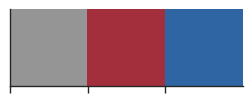

In [18]:
custom_palette = ["#959595", "#A32F3C", "#2F65A3"]  # Define hex colors
palette = sns.color_palette(custom_palette, as_cmap=True)
sns.palplot(custom_palette)

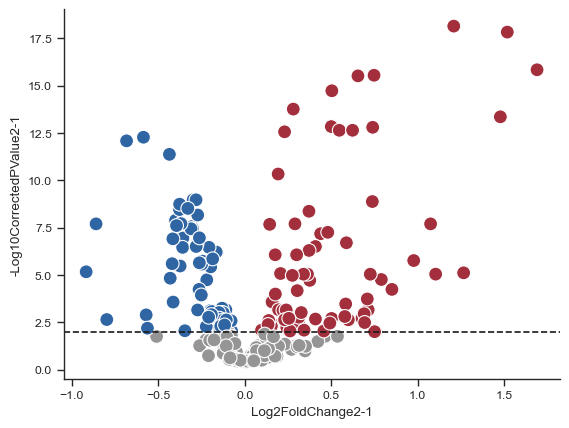

In [19]:
ax = sns.scatterplot(
    data=quant_matrix_de,
    x="Log2FoldChange2-1",
    y="-Log10CorrectedPValue2-1",
    hue="Color",
    s=100,
    #alpha=0.8,
    legend=False,
    palette=palette
)

ax.axhline(
    -np.log10(0.01), c="k", linestyle="--"
)
sns.despine()
#ax.figure.set_size_inches((3, 3))

In [20]:
ax.figure.savefig(
    "sepsis_volcano.pdf", dpi=300, bbox_inches="tight"
)

In [21]:
qm_df = quant_matrix_train.to_df()

pos_df = qm_df[qm_df['Log2FoldChange2-1'] > 0]
neg_df = qm_df[qm_df['Log2FoldChange2-1'] < 0]

In [22]:
pos_qm = QuantMatrix(
    quantification_file=pos_df,
    design_matrix_file=design_matrix_train,
)

pos_qm.annotated = True

enr = pos_qm.enrich(
    method="enrichr_overreptest",
    libraries=['GO_Biological_Process_2023'],
    filter_pvalue=True,
    pvalue_column="CorrectedPValue2-1",
    pvalue_cutoff=0.01
)

In [23]:
base_color = "#A32F3C"

In [24]:
cmap = sns.color_palette("Reds_d", as_cmap=True)

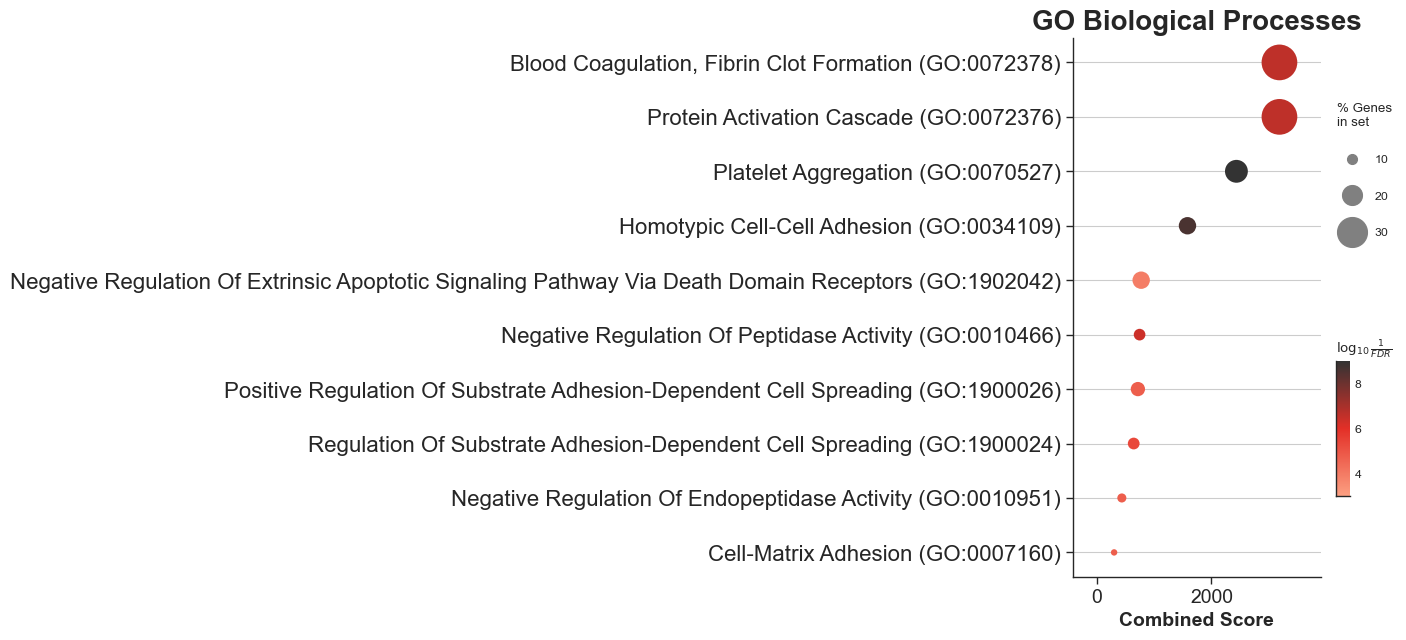

In [25]:
# simple plotting function

from gseapy import barplot, dotplot

ax = dotplot(
    enr.res2d, 
    title='GO Biological Processes',
    cmap=cmap, 
    size=15,
    figsize=(4,7),
    #cutoff=1,
    top_term=10
    
)

sns.despine()

In [26]:
ax.figure.savefig(
    "sepsis_pathways_positive.pdf", dpi=300, bbox_inches="tight"
)

In [27]:
enr.res2d.to_csv(
    "sepsis_pathways_positive.tsv",
    sep="\t",
)

In [28]:
neg_qm = QuantMatrix(
    quantification_file=neg_df,
    design_matrix_file=design_matrix_train,
)

neg_qm.annotated = True

enr = neg_qm.enrich(
    method="enrichr_overreptest",
    libraries=['GO_Biological_Process_2023'],
    filter_pvalue=True,
    pvalue_column="CorrectedPValue2-1",
    pvalue_cutoff=0.01
)

In [29]:
base_color = "#2f5da3"

In [30]:
cmap = sns.color_palette("Blues_d", as_cmap=True)

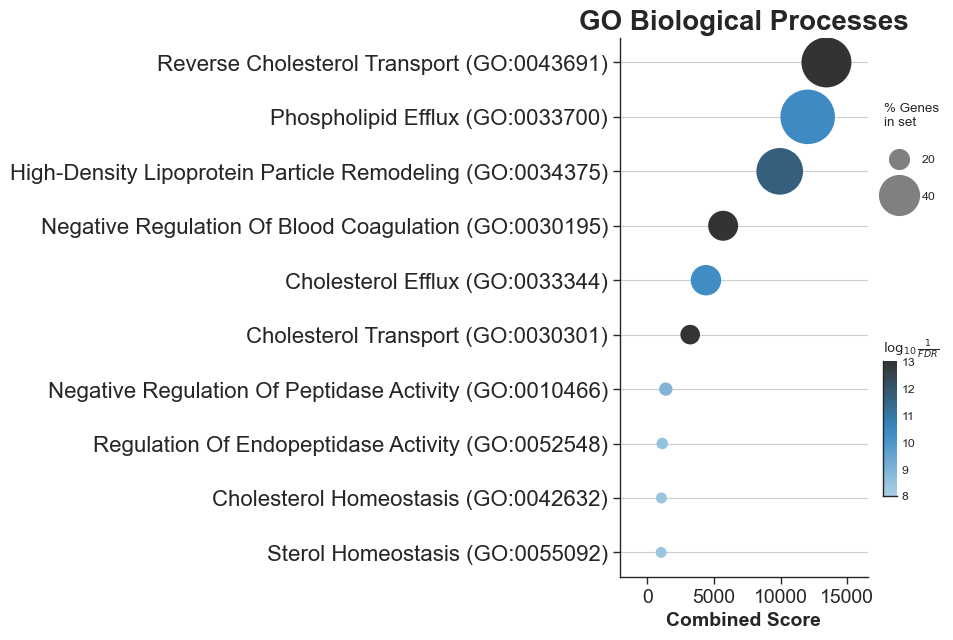

In [31]:
# simple plotting function

from gseapy import barplot, dotplot

ax = dotplot(
    enr.res2d,
    title='GO Biological Processes',
    cmap=cmap,
    size=15,
    figsize=(4,7),
    cutoff=1,
    top_term=10

)

sns.despine()

In [32]:
ax.figure.savefig(
    "sepsis_pathways_negative.pdf", dpi=300, bbox_inches="tight"
)

In [33]:
enr.res2d.to_csv(
    "sepsis_pathways_negative.tsv",
    sep="\t",
)

<Axes: >

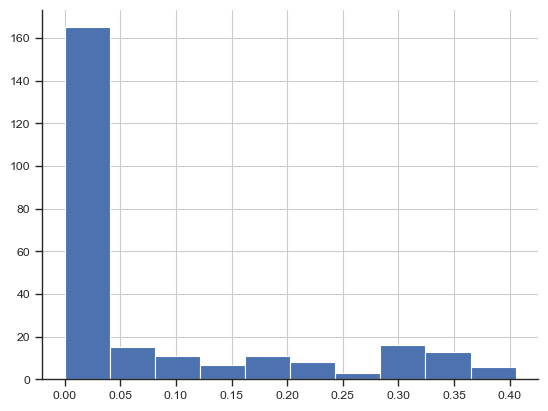

In [34]:
quant_matrix_de['CorrectedPValue2-1'].hist()

In [35]:
qm_filtered = (
    
    QuantMatrix(
        quantification_file=quant_matrix_de,
        design_matrix_file=design_matrix_train
    )
    
)

In [36]:
training_data, y = qm_filtered.to_ml(feature_column="ProteinLabel")

In [37]:
protein_columns = training_data.columns.to_list()

In [38]:
len(protein_columns)

255

In [39]:
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.impute import SimpleImputer

X = training_data.copy()

protein_scaler = StandardScaler()

X[protein_columns] = protein_scaler.fit_transform(X[protein_columns])

X = X.copy()

In [40]:
from sklearn.utils.class_weight import compute_class_weight


class_weight = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y.values.ravel()),
    y=y.values.ravel()
)

class_weight = dict(zip(np.unique(y.values.ravel()), class_weight))

class_weight

{0: 1.1619718309859155, 1: 0.8776595744680851}

In [41]:
from mrmr import mrmr_classif
selected_proteins = mrmr_classif(X=X[protein_columns], y=y.values.ravel(), K=50)

100%|██████████| 50/50 [00:00<00:00, 63.98it/s]


In [42]:
selected_proteins

['TIMP1_HUMAN',
 'F13A_HUMAN',
 'APOF_HUMAN',
 'CRP_HUMAN',
 'VWF_HUMAN',
 'ALS_HUMAN',
 'SAA2_HUMAN',
 'B2MG_HUMAN',
 'LBP_HUMAN',
 'IBP3_HUMAN',
 'SAA1_HUMAN',
 'CYTC_HUMAN',
 'THBG_HUMAN',
 'AACT_HUMAN',
 'FBLN5_HUMAN',
 'FIBA_HUMAN',
 'KLKB1_HUMAN',
 'A2GL_HUMAN',
 'FIBG_HUMAN',
 'CLUS_HUMAN',
 'FIBB_HUMAN',
 'FETUA_HUMAN',
 'CATB_HUMAN',
 'ENPL_HUMAN',
 'FETUB_HUMAN',
 'PSPB_HUMAN',
 'PROC_HUMAN',
 'CHLE_HUMAN',
 'CFAD_HUMAN',
 'APOC1_HUMAN',
 'LYSC_HUMAN',
 'ITIH3_HUMAN',
 'APOL1_HUMAN',
 'PCSK9_HUMAN',
 'FGL1_HUMAN',
 'A1AT_HUMAN',
 'F13B_HUMAN',
 'VCAM1_HUMAN',
 'PGRP2_HUMAN',
 'PPIA_HUMAN',
 'BTD_HUMAN',
 'CALR_HUMAN',
 'APOM_HUMAN',
 'H4_HUMAN',
 'CD14_HUMAN',
 'SPP24_HUMAN',
 'HRG_HUMAN',
 'LDHB_HUMAN',
 'SEPP1_HUMAN',
 'IBP2_HUMAN']

In [43]:
from sklearn.linear_model import LogisticRegression



# protein_clf = LogisticRegression(
#     random_state=42,
#     penalty="l1",
#     class_weight=class_weight,
#     C=1,
#     solver="liblinear",
#     max_iter=1000
# )

protein_clf = LogisticRegression(
    class_weight=class_weight,
    random_state=42
)

In [44]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_validate

cv = StratifiedKFold(3)
eval_result = cross_validate(
    protein_clf, X[selected_proteins], y.values.ravel(), scoring=("recall", "precision", "accuracy", "balanced_accuracy"), cv=cv,
)
eval_result['test_recall'].mean(), eval_result['test_precision'].mean(), eval_result['test_accuracy'].mean(), eval_result['test_balanced_accuracy'].mean()

(0.8247994538317119, 0.8217825507395942, 0.796969696969697, 0.792792752920584)

In [45]:
from dpks.interpretation import BootstrapInterpreter

protein_interpreter = BootstrapInterpreter(
    n_iterations=100,
    feature_names=selected_proteins,
    downsample_background=True,
    shuffle_iterations=100
)

In [46]:
protein_interpreter.fit(X[selected_proteins].values, y.values.ravel(), protein_clf)

In [47]:
protein_importances = protein_interpreter.results_.sort_values("mean_importance", ascending=False)

In [48]:
protein_importances.head(20)

,feature,iteration_0_importance,iteration_0_rank,iteration_1_importance,iteration_1_rank,iteration_2_importance,iteration_2_rank,iteration_3_importance,iteration_3_rank,iteration_4_importance,...,iteration_98_importance,iteration_98_rank,iteration_99_importance,iteration_99_rank,mean_importance,median_importance,stdev_importance,mean_rank,median_rank,stdev_rank
42,APOM_HUMAN,0.245120,18.0,1.000000,1.0,0.747868,4.0,0.598658,2.0,0.735209,...,0.942796,2.0,0.897658,3.0,0.782967,0.872565,0.235735,4.13,2.0,4.556392
4,VWF_HUMAN,0.727262,2.0,0.601310,4.0,0.754972,3.0,1.000000,1.0,1.000000,...,0.428156,11.0,0.727821,8.0,0.777694,0.766646,0.173373,3.75,3.0,2.875796
11,CYTC_HUMAN,0.261879,16.0,0.895400,2.0,0.617079,5.0,0.048954,41.0,0.686489,...,0.870807,4.0,0.851923,4.0,0.610319,0.614775,0.262963,9.04,5.0,9.322418
16,KLKB1_HUMAN,0.026505,47.0,0.770240,3.0,0.331268,16.0,0.189227,26.0,0.175783,...,0.114895,39.0,0.806117,5.0,0.472717,0.495188,0.230545,13.36,9.0,11.715931
6,SAA2_HUMAN,0.316632,11.0,0.528333,5.0,0.585703,6.0,0.425467,5.0,0.867241,...,0.671440,7.0,0.711418,9.0,0.471958,0.450259,0.291110,15.97,9.0,14.887087
8,LBP_HUMAN,1.000000,1.0,0.129405,40.0,0.272463,19.0,0.415255,6.0,0.413056,...,1.000000,1.0,0.747010,6.0,0.454768,0.428360,0.266713,15.64,11.0,13.429592
37,VCAM1_HUMAN,0.406818,6.0,0.456672,8.0,0.371460,12.0,0.465253,4.0,0.186688,...,0.314155,23.0,0.732274,7.0,0.446318,0.459779,0.196558,13.65,11.5,10.358596
9,IBP3_HUMAN,0.155756,29.0,0.384754,11.0,0.542717,7.0,0.242895,19.0,0.580307,...,0.386461,15.0,0.046593,48.0,0.432161,0.445435,0.258612,16.56,10.0,14.057113
34,FGL1_HUMAN,0.059910,39.0,0.214296,23.0,0.309410,17.0,0.218171,23.0,0.381710,...,0.888491,3.0,0.530316,15.0,0.399264,0.381666,0.216305,16.88,13.0,12.100822
13,AACT_HUMAN,0.521419,4.0,0.145320,35.0,0.850725,2.0,0.507356,3.0,0.887492,...,0.755157,5.0,0.903898,2.0,0.395087,0.381682,0.260879,19.11,14.0,14.931422


In [49]:
selected_proteins = protein_importances.head(10)['feature'].to_list()

In [50]:
from dpks.interpretation import Classifier


protein_clf = Classifier(protein_clf)

In [51]:
selected_features = selected_proteins[:10]

In [52]:
for feature in selected_features:

    print(feature)

APOM_HUMAN
VWF_HUMAN
CYTC_HUMAN
KLKB1_HUMAN
SAA2_HUMAN
LBP_HUMAN
VCAM1_HUMAN
IBP3_HUMAN
FGL1_HUMAN
AACT_HUMAN


In [53]:
protein_clf = LogisticRegression(
    class_weight=class_weight,
    random_state=42
)

In [54]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_validate


eval_result = cross_validate(
    protein_clf, X[selected_features], y.values.ravel(), scoring=("recall", "precision", "accuracy", "balanced_accuracy"), cv=cv,
)
eval_result['test_recall'].mean(), eval_result['test_precision'].mean(), eval_result['test_accuracy'].mean(), eval_result['test_balanced_accuracy'].mean()

(0.8195084485407066,
 0.8552804937244297,
 0.8151515151515151,
 0.8150438223791004)

In [55]:

eval_result = cross_validate(
    protein_clf, X[protein_columns], y.values.ravel(), scoring=("recall", "precision", "accuracy", "balanced_accuracy"), cv=cv,
)
eval_result['test_recall'].mean(), eval_result['test_precision'].mean(), eval_result['test_accuracy'].mean(), eval_result['test_balanced_accuracy'].mean()

(0.7875064004096263,
 0.7711620469083155,
 0.7424242424242425,
 0.7355085193537493)

In [56]:
from dpks.interpretation import BootstrapInterpreter

final_protein_interpreter = BootstrapInterpreter(
    n_iterations=100,
    feature_names=selected_features,
    downsample_background=True,
    shuffle_iterations=100
)

In [57]:
final_protein_interpreter.fit(X[selected_features].values, y.values.ravel(), protein_clf)

In [58]:
final_protein_importances = final_protein_interpreter.results_.sort_values("mean_importance", ascending=False)

In [59]:
final_protein_importances

,feature,iteration_0_importance,iteration_0_rank,iteration_1_importance,iteration_1_rank,iteration_2_importance,iteration_2_rank,iteration_3_importance,iteration_3_rank,iteration_4_importance,...,iteration_98_importance,iteration_98_rank,iteration_99_importance,iteration_99_rank,mean_importance,median_importance,stdev_importance,mean_rank,median_rank,stdev_rank
1,VWF_HUMAN,0.805491,2.0,0.522859,4.0,1.000000,1.0,0.894328,2.0,1.000000,...,0.814557,3.0,1.000000,1.0,0.886954,0.978738,0.148788,1.94,2.0,1.170513
4,SAA2_HUMAN,0.075537,10.0,1.000000,1.0,0.603259,5.0,1.000000,1.0,0.792767,...,1.000000,1.0,0.332385,6.0,0.683497,0.728266,0.269633,3.53,3.0,2.285019
2,CYTC_HUMAN,0.469989,3.0,0.611057,3.0,0.663642,2.0,0.497046,4.0,0.672944,...,0.833034,2.0,0.914071,3.0,0.657680,0.633419,0.189117,3.37,3.0,1.411747
3,KLKB1_HUMAN,0.198097,5.0,0.705422,2.0,0.360510,7.0,0.296747,8.0,0.674515,...,0.619137,6.0,0.990422,2.0,0.598928,0.589605,0.238904,4.08,4.0,2.028484
7,IBP3_HUMAN,0.451457,4.0,0.284145,7.0,0.646788,3.0,0.459557,6.0,0.383660,...,0.721975,5.0,0.251578,8.0,0.569107,0.553149,0.225960,4.52,4.5,2.007461
5,LBP_HUMAN,1.000000,1.0,0.100129,8.0,0.635607,4.0,0.492068,5.0,0.522240,...,0.723173,4.0,0.668514,5.0,0.452725,0.426816,0.268585,5.74,6.0,2.414686
6,VCAM1_HUMAN,0.162389,6.0,0.306460,6.0,0.209291,8.0,0.241160,9.0,0.018473,...,0.070929,10.0,0.720335,4.0,0.292834,0.285933,0.161444,7.02,7.0,1.842155
9,AACT_HUMAN,0.099910,8.0,0.011405,10.0,0.396674,6.0,0.541431,3.0,0.527966,...,0.407393,7.0,0.193755,9.0,0.226314,0.218133,0.147493,7.98,8.0,1.626672
0,APOM_HUMAN,0.120141,7.0,0.421504,5.0,0.202171,9.0,0.148062,10.0,0.047620,...,0.119963,9.0,0.132481,10.0,0.194843,0.148724,0.153290,8.31,9.0,1.599842
8,FGL1_HUMAN,0.094264,9.0,0.070311,9.0,0.014125,10.0,0.386541,7.0,0.231414,...,0.325021,8.0,0.262207,7.0,0.169477,0.143743,0.133015,8.51,9.0,1.459867


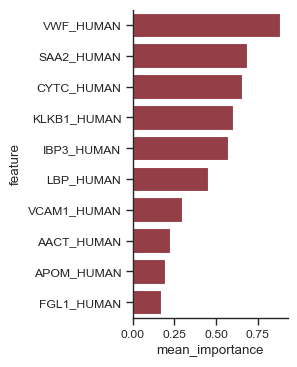

In [60]:

g = sns.barplot(
    data=final_protein_importances,
    y="feature",
    x="mean_importance",
    color="#A32F3C"
)

g.figure.set_size_inches((2, 4))

sns.despine()

In [61]:
g.figure.savefig(
    "sepsis_feature_importances.pdf", dpi=300, bbox_inches="tight"
)

In [62]:
final_protein_importances.to_csv(
    "sepsis_feature_importances.tsv",
    sep="\t",
    index=False
)

In [68]:
design_matrix_train = design_matrix_train.set_index("injection").join(X[selected_features])

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

model = AgglomerativeClustering(n_clusters=2)
design_matrix_train['Cluster'] = model.fit_predict(design_matrix_train[selected_features])
print(silhouette_score(design_matrix_train[selected_features], design_matrix_train['Cluster']))



0.19539960406750484


In [71]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans


In [72]:
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(context="paper", style="ticks", rc=custom_params, font="Arial", font_scale=1.5)


K = range(2,
          X.shape[0]
          )

wcss = []
silhouette_scores = []

for k in K:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X[selected_features])
    cluster_labels = kmeans.fit_predict(X[selected_features])
    silhouette_avg = silhouette_score(X[selected_features], cluster_labels)
    silhouette_scores.append(silhouette_avg)
    wcss.append(kmeans.inertia_)



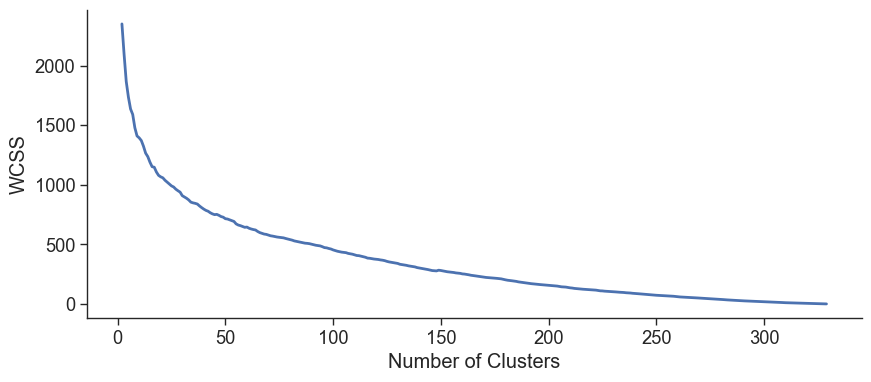

In [73]:
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(context="paper", style="ticks", rc=custom_params, font="Arial", font_scale=1.5)

fig, ax = plt.subplots(figsize=(10, 4))

sns.lineplot(
    x=K,
    y=wcss,
    ax=ax,
    lw=2
)

ax.set_xlabel('Number of Clusters')
ax.set_ylabel('WCSS')

fig.savefig("elbow.pdf", dpi=300, bbox_inches="tight")


In [74]:
from kneed import KneeLocator

kneedle = KneeLocator(K, wcss, curve="convex", direction="decreasing")

In [75]:
print(round(kneedle.knee, 3))

print(round(kneedle.elbow, 3))

44
44


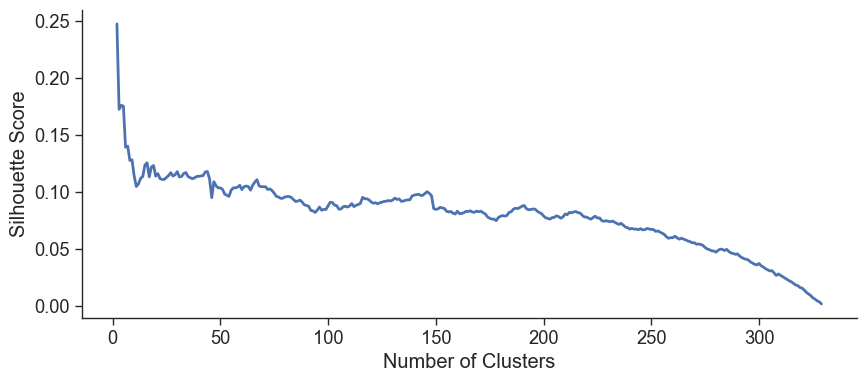

In [76]:
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(context="paper", style="ticks", rc=custom_params, font="Arial", font_scale=1.5)

fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(
    x=K,
    y=silhouette_scores,
    lw=2
)
#ax.title('Silhouette Scores')
ax.set_xlabel('Number of Clusters')
ax.set_ylabel('Silhouette Score')

fig.savefig("sillhoute_scores.pdf", dpi=300, bbox_inches="tight")


In [77]:
data = np.array(silhouette_scores[42:200])

mean_silhoutte_score = np.mean(data)

mad = np.mean(np.abs(data - mean_silhoutte_score))
mad

0.007167521833462401

In [78]:
final_protein_importances

,feature,iteration_0_importance,iteration_0_rank,iteration_1_importance,iteration_1_rank,iteration_2_importance,iteration_2_rank,iteration_3_importance,iteration_3_rank,iteration_4_importance,...,iteration_98_importance,iteration_98_rank,iteration_99_importance,iteration_99_rank,mean_importance,median_importance,stdev_importance,mean_rank,median_rank,stdev_rank
1,VWF_HUMAN,0.805491,2.0,0.522859,4.0,1.000000,1.0,0.894328,2.0,1.000000,...,0.814557,3.0,1.000000,1.0,0.886954,0.978738,0.148788,1.94,2.0,1.170513
4,SAA2_HUMAN,0.075537,10.0,1.000000,1.0,0.603259,5.0,1.000000,1.0,0.792767,...,1.000000,1.0,0.332385,6.0,0.683497,0.728266,0.269633,3.53,3.0,2.285019
2,CYTC_HUMAN,0.469989,3.0,0.611057,3.0,0.663642,2.0,0.497046,4.0,0.672944,...,0.833034,2.0,0.914071,3.0,0.657680,0.633419,0.189117,3.37,3.0,1.411747
3,KLKB1_HUMAN,0.198097,5.0,0.705422,2.0,0.360510,7.0,0.296747,8.0,0.674515,...,0.619137,6.0,0.990422,2.0,0.598928,0.589605,0.238904,4.08,4.0,2.028484
7,IBP3_HUMAN,0.451457,4.0,0.284145,7.0,0.646788,3.0,0.459557,6.0,0.383660,...,0.721975,5.0,0.251578,8.0,0.569107,0.553149,0.225960,4.52,4.5,2.007461
5,LBP_HUMAN,1.000000,1.0,0.100129,8.0,0.635607,4.0,0.492068,5.0,0.522240,...,0.723173,4.0,0.668514,5.0,0.452725,0.426816,0.268585,5.74,6.0,2.414686
6,VCAM1_HUMAN,0.162389,6.0,0.306460,6.0,0.209291,8.0,0.241160,9.0,0.018473,...,0.070929,10.0,0.720335,4.0,0.292834,0.285933,0.161444,7.02,7.0,1.842155
9,AACT_HUMAN,0.099910,8.0,0.011405,10.0,0.396674,6.0,0.541431,3.0,0.527966,...,0.407393,7.0,0.193755,9.0,0.226314,0.218133,0.147493,7.98,8.0,1.626672
0,APOM_HUMAN,0.120141,7.0,0.421504,5.0,0.202171,9.0,0.148062,10.0,0.047620,...,0.119963,9.0,0.132481,10.0,0.194843,0.148724,0.153290,8.31,9.0,1.599842
8,FGL1_HUMAN,0.094264,9.0,0.070311,9.0,0.014125,10.0,0.386541,7.0,0.231414,...,0.325021,8.0,0.262207,7.0,0.169477,0.143743,0.133015,8.51,9.0,1.459867


In [79]:
from joblib import dump

with open("sepsis.clf", "wb") as f:

    dump(protein_clf, f)

with open("sepsis.scaler", "wb") as f:

    dump(protein_scaler, f)